<a href="https://colab.research.google.com/github/isamadafridi/Pneumonia-Detection-using-Chest-X-Ray/blob/main/Pneumonia_Detection_using_Chest_X_Ray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras.layers import InputLayer, Conv2D, BatchNormalization, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [ ]:
dataset, dataset_info = tfds.load('pneumonia_mnist', with_info=True, as_supervised=True, shuffle_files=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/pneumonia_mnist/incomplete.KD8D7O_1.0.0/pneumonia_mnist-train.tfrecord*...…

Generating val examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/pneumonia_mnist/incomplete.KD8D7O_1.0.0/pneumonia_mnist-val.tfrecord*...: …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/pneumonia_mnist/incomplete.KD8D7O_1.0.0/pneumonia_mnist-test.tfrecord*...:…

Dataset pneumonia_mnist downloaded and prepared to /root/tensorflow_datasets/pneumonia_mnist/1.0.0. Subsequent calls will reuse this data.


In [ ]:
dataset_info

tfds.core.DatasetInfo(
    name='pneumonia_mnist',
    full_name='pneumonia_mnist/1.0.0',
    description="""
    # MedMNIST Pneumonia Dataset
    
    The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray
    images. The task is binary-class classification of pneumonia against normal. The
    source training set is split with a ratio of 9:1 into training and validation
    set, and use its source validation set as the test set. The source images are
    gray-scale, and their sizes are (384–2,916) × (127–2,713). The images are
    center-cropped with a window size of length of the short edge and resized into 1
    × 28 × 28.
    """,
    homepage='https://medmnist.com//',
    data_dir='/root/tensorflow_datasets/pneumonia_mnist/1.0.0',
    file_format=tfrecord,
    download_size=3.98 MiB,
    dataset_size=3.66 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),

In [ ]:
# The pneumonia_mnist dataset already provides train, validation, and test splits.
# We can access them directly from the 'dataset' variable using their keys.
train_dataset = dataset['train']
val_dataset = dataset['val']
test_dataset = dataset['test']

In [ ]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
for image, label in train_dataset.take(4):
  print(f"Image shape: {image.shape}, Label: {label.numpy()}")

Image shape: (28, 28, 1), Label: 0
Image shape: (28, 28, 1), Label: 1
Image shape: (28, 28, 1), Label: 0
Image shape: (28, 28, 1), Label: 1


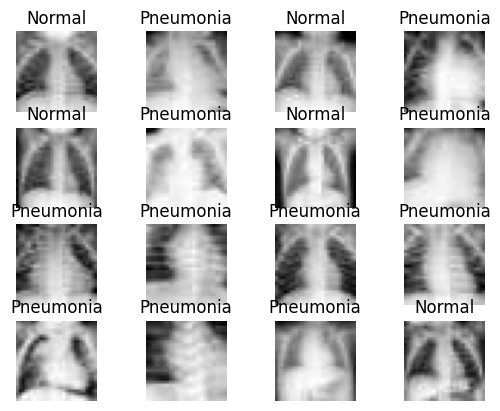

In [ ]:
for i, (image, label) in enumerate(train_dataset.take(16)):
  ax = plt.subplot(4,4, i + 1)
  plt.imshow(image, cmap = 'gray') # cmap are use for color
  plt.title(dataset_info.features['label'].int2str(label))
  plt.axis('off')

In [ ]:
val_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
IM_SIZE = 224
def resize_rescale(image, label):
  return tf.image.resize(image, (IM_SIZE, IM_SIZE)),label

In [ ]:
train_dataset = train_dataset.map(resize_rescale)
val_dataset = val_dataset.map(resize_rescale)
test_dataset = test_dataset.map(resize_rescale)

In [ ]:
val_dataset

<_MapDataset element_spec=(TensorSpec(shape=(224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
for image,label in train_dataset.take(1):
  print(image, label)

tf.Tensor(
[[[141.]
  [141.]
  [141.]
  ...
  [141.]
  [141.]
  [141.]]

 [[141.]
  [141.]
  [141.]
  ...
  [141.]
  [141.]
  [141.]]

 [[141.]
  [141.]
  [141.]
  ...
  [141.]
  [141.]
  [141.]]

 ...

 [[159.]
  [159.]
  [159.]
  ...
  [194.]
  [194.]
  [194.]]

 [[159.]
  [159.]
  [159.]
  ...
  [194.]
  [194.]
  [194.]]

 [[159.]
  [159.]
  [159.]
  ...
  [194.]
  [194.]
  [194.]]], shape=(224, 224, 1), dtype=float32) tf.Tensor(0, shape=(), dtype=int64)


In [ ]:
BATCH_SIZE = 32
train_dataset = train_dataset.shuffle(buffer_size=8, reshuffle_each_iteration=True).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
val_dataset = val_dataset.shuffle(buffer_size=8, reshuffle_each_iteration=True).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# **MOdel Definetion**

In [ ]:
mnist_model = tf.keras.Sequential([
                                    InputLayer(input_shape = (IM_SIZE, IM_SIZE, 1)),

                                    Conv2D(filters=6 , kernel_size=3, strides=1, padding='valid', activation='relu'),
                                    BatchNormalization(),
                                    MaxPool2D(pool_size=2, strides=2),
                                    Dropout(0.25),

                                    Conv2D(filters=16, kernel_size=3, strides=1, padding='valid', activation='relu'),
                                    BatchNormalization(),
                                    MaxPool2D(pool_size=2, strides=2),
                                    Dropout(0.25),

                                    Flatten(),

                                    Dense(32, activation='relu'),
                                    BatchNormalization(),
                                    Dropout(0.5),

                                    Dense(8, activation='relu'),
                                    Dropout(0.5),



                                    Dense(1, activation='sigmoid')





])
mnist_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 6)    │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     1,493,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,494,453 (5.70 MB)

 Trainable params: 1,494,345 (5.70 MB)

 Non-trainable params: 108 (432.00 B)

In [ ]:
mnist_model.compile(optimizer=Adam(learning_rate=0.01),
                    loss = BinaryCrossentropy(),
                    metrics = ['accuracy']
                    )

In [ ]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [ ]:
val_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [ ]:
model_fiiting = mnist_model.fit(train_dataset, validation_data=val_dataset, epochs=50, verbose=1)

Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - accuracy: 0.8025 - loss: 0.4735 - val_accuracy: 0.9313 - val_loss: 0.1829
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9168 - loss: 0.2216 - val_accuracy: 0.9637 - val_loss: 0.1183
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9284 - loss: 0.1988 - val_accuracy: 0.9695 - val_loss: 0.0926
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9339 - loss: 0.1829 - val_accuracy: 0.9237 - val_loss: 0.1733
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9310 - loss: 0.1887 - val_accuracy: 0.9542 - val_loss: 0.6536
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9361 - loss: 0.1842 - val_accuracy: 0.8015 - val_loss: 0.5928
Epoch 7/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9388 - loss: 0.1716 - val_accuracy: 0.9561 - val_loss: 0.1226
Epoch 8/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9368 - loss: 0.1690 - val_acc

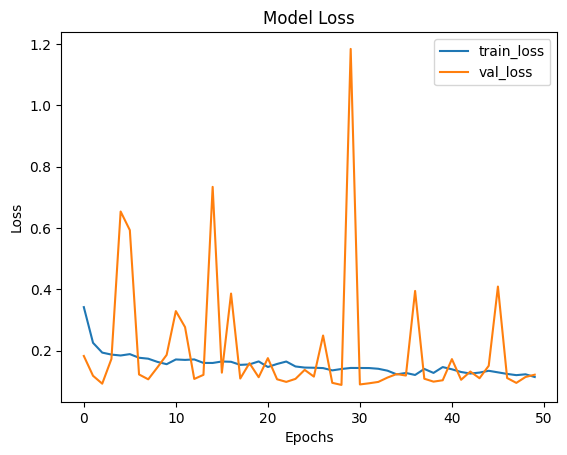

In [ ]:
plt.plot(model_fiiting.history['loss'])
plt.plot(model_fiiting.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train_loss', 'val_loss'])
plt.show()

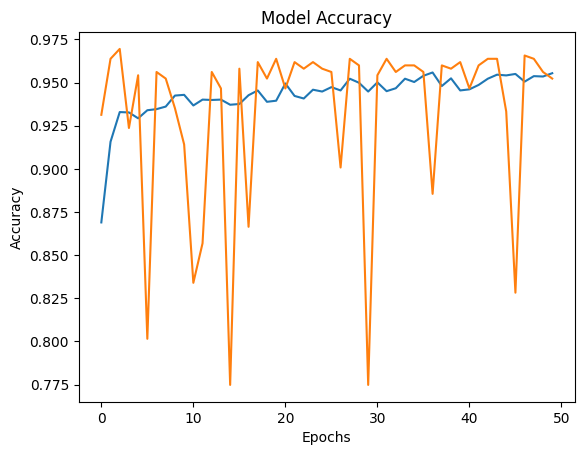

In [ ]:
plt.plot(model_fiiting.history['accuracy'])
plt.plot(model_fiiting.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

# **Model Evaluation And Testing**

In [ ]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [ ]:
test_dataset

<_MapDataset element_spec=(TensorSpec(shape=(224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
test_dataset = test_dataset.batch(1)

In [ ]:
test_dataset

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [ ]:
mnist_model.evaluate(test_dataset)

624/624 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8126 - loss: 0.8148


[0.8576123118400574, 0.8028846383094788]

# **Model Predection**

In [ ]:
def pos_or_neg(x):
  if (x >= 0.5):
      return str('Negitive')
  else:
      return str('Positive')

In [ ]:
pos_or_neg(mnist_model.predict(test_dataset.take(2))[0][0])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 


'Negitive'